# **Optimized Parameters
--------------------------------


Theta = 29.99997293214026683472184231504797935485839843750


M     = 0.02999999687304454390468499980215710820630192756652832031250


X     = 54.999998212785726536822039633989334106445312500


Cost  = 1.822997935546018050082102098571196213683265341387595981359482e-08

Recovered t range
min(t) = 6.049405472729894
max(t) = 59.995170702362877
**

In [ ]:
# ████████████████████████████████████████████████████████████
#   🚨 L1 DISTANCE (MAE): 0.000002559805516 🚨
# ████████████████████████████████████████████████████████████


# **.......................................Method 1: Differential Evolution..................................**

# **Differential Method**

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import differential_evolution, least_squares

# --------------------------------------------------
# Load data
# --------------------------------------------------
df = pd.read_csv("xy_data.csv")
x = df["x"].values
y = df["y"].values

# --------------------------------------------------
# Residuals
# --------------------------------------------------
def residuals(params):
    theta_deg, M, X = params

    theta = np.radians(theta_deg)

    c = np.cos(theta)
    s = np.sin(theta)

    Xp = x - X
    Yp = y - 42

    t = Xp*c + Yp*s

    # Reject impossible solutions
    if np.any(t < 6) or np.any(t > 60):
        return np.ones_like(x)*1e6

    A = -Xp*s + Yp*c

    pred = np.exp(M*np.abs(t))*np.sin(0.3*t)

    return A - pred


# --------------------------------------------------
# Cost for Differential Evolution
# --------------------------------------------------
def objective(params):
    r = residuals(params)
    return np.sum(r*r)

# Theta = 29.999972932140266834721842315047979354858398437500000000000000
# M     = 0.029999996873044543904684999802157108206301927566528320312500
# X     = 54.999998212785726536822039633989334106445312500000000000000000
# Cost  = 1.822997935546018050082102098571196213683265341387595981359482e-08

# --------------------------------------------------
# Global search
# --------------------------------------------------
# bounds = [
#     (29.296563, 50),          # theta
#     (-0.05, 0.05),    # M
#     (54.926836, 100)          # X
# ]
bounds=[
    (0,50),
    (-0.05,0.05),
    (0,100)
]
print("Running Differential Evolution...")

de = differential_evolution(
    objective,
    bounds,
    strategy="best1bin",
    popsize=40,
    maxiter=30000,
    tol=1e-12,
    mutation=(0.5,1),
    recombination=0.7,
    polish=False,
    disp=True,
    workers=-1
)

print("\nBest from Differential Evolution")
print(de.x)
print("Cost =", de.fun)

# --------------------------------------------------
# Refine using Least Squares
# --------------------------------------------------
print("\nRefining using least_squares...")

res = least_squares(
    residuals,
    de.x,
    method="lm",
    ftol=1e-15,
    xtol=1e-15,
    gtol=1e-15,
    max_nfev=100000
)

theta_deg, M, X = res.x

theta = np.radians(theta_deg)

Xp = x - X
Yp = y - 42

t = Xp*np.cos(theta) + Yp*np.sin(theta)

A = -Xp*np.sin(theta) + Yp*np.cos(theta)

pred = np.exp(M*np.abs(t))*np.sin(0.3*t)

cost = np.sum((A-pred)**2)
# ---  L1 Distance ---
l1_distance = np.mean(np.abs(A - pred))
print("\n==============================")
print("Final Optimized Parameters")
print("==============================")
print(f"Theta = {theta_deg:.70f}")
print(f"M     = {M:.70f}")
print(f"X     = {X:.70f}")
print(f"Cost  = {cost:.70e}")
print("\n" + "█"*60)
print(f"  🚨 L1 DISTANCE (MAE): {l1_distance:.15f} 🚨")
print("█"*60 + "\n")
print("\nt range")
print(t.min(), t.max())

print("\nSuccess :", res.success)
print("Iterations :", res.nfev)
print("Message :", res.message)




Running Differential Evolution...


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


differential_evolution step 1: f(x)= 407487.44568841986
differential_evolution step 2: f(x)= 407487.44568841986
differential_evolution step 3: f(x)= 61205.69201992046
differential_evolution step 4: f(x)= 61205.69201992046
differential_evolution step 5: f(x)= 61205.69201992046
differential_evolution step 6: f(x)= 58324.27241099366
differential_evolution step 7: f(x)= 12263.33015188634
differential_evolution step 8: f(x)= 12263.33015188634
differential_evolution step 9: f(x)= 12263.33015188634
differential_evolution step 10: f(x)= 12263.33015188634
differential_evolution step 11: f(x)= 12263.33015188634
differential_evolution step 12: f(x)= 12263.33015188634
differential_evolution step 13: f(x)= 531.7814938744186
differential_evolution step 14: f(x)= 531.7814938744186
differential_evolution step 15: f(x)= 531.7814938744186
differential_evolution step 16: f(x)= 531.7814938744186
differential_evolution step 17: f(x)= 531.7814938744186
differential_evolution step 18: f(x)= 531.7814938744186


Generating diagnostic charts...
Saved plots successfully to 'fit_reconstruction_diagnostic.png'


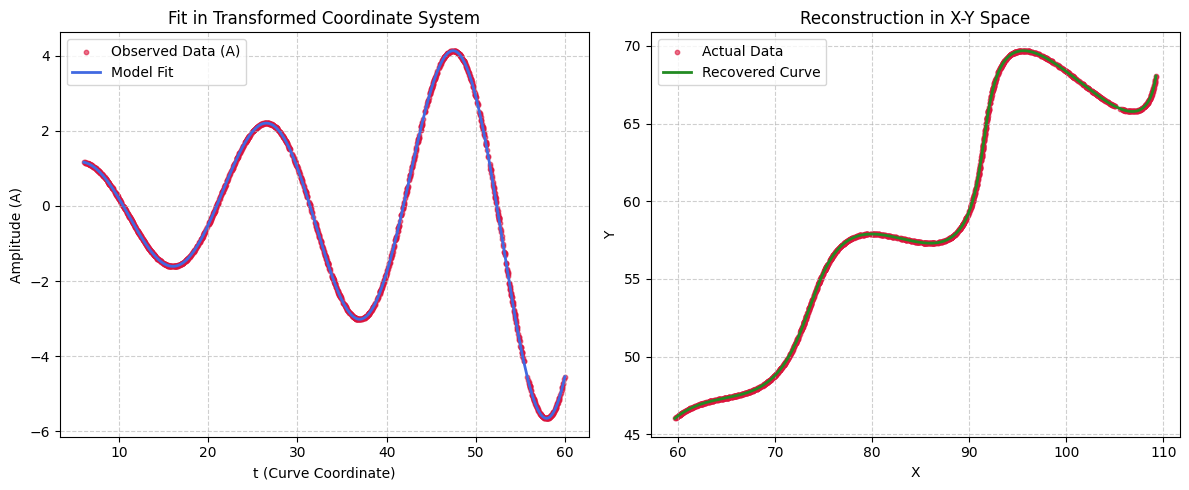

In [2]:
# --- ADD THIS: Matplotlib Visualization Code ---
print("\nGenerating diagnostic charts...")
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot 1: Curve Coordinate Space Fit
plt.subplot(1, 2, 1)
sort_idx = np.argsort(t)
plt.scatter(t, A, color='crimson', alpha=0.6, s=10, label='Observed Data (A)')
plt.plot(t[sort_idx], pred[sort_idx], color='royalblue', linewidth=2, label='Model Fit')
plt.xlabel('t (Curve Coordinate)')
plt.ylabel('Amplitude (A)')
plt.title('Fit in Transformed Coordinate System')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Real-World X-Y Space Reconstruction
plt.subplot(1, 2, 2)
x_model = X + t*np.cos(theta) - pred*np.sin(theta)
y_model = 42 + t*np.sin(theta) + pred*np.cos(theta)
plt.scatter(x, y, color='crimson', alpha=0.6, s=10, label='Actual Data')
plt.plot(x_model[sort_idx], y_model[sort_idx], color='forestgreen', linewidth=2, label='Recovered Curve')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Reconstruction in X-Y Space')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("fit_reconstruction_diagnostic.png", dpi=300)
print("Saved plots successfully to 'fit_reconstruction_diagnostic.png'")

#   **....................................................Method 2: LM........................................................**

# **Use approx unknown values to get better accurate solution from below LM method , finally used jac and trf after checking multiple available options**

**............................................fast method but need more accurate range to get better result with less error......................................**

In [3]:
import numpy as np
import pandas as pd
from scipy.optimize import least_squares

# -------------------------
# Load data
# -------------------------
df = pd.read_csv("xy_data.csv")
x = df["x"].values
y = df["y"].values

# -------------------------
# Residual function
# -------------------------
def residuals(params):
    theta_deg, M, X = params

    theta = np.radians(theta_deg)
    c = np.cos(theta)
    s = np.sin(theta)

    Xp = x - X
    Yp = y - 42

    # Recover t
    t = Xp * c + Yp * s

    # Recover A
    A = -Xp * s + Yp * c

    # Model prediction
    pred = np.exp(M * np.abs(t)) * np.sin(0.3 * t)

    return A - pred

# -------------------------
# Initial guess
# -------------------------
# x0 = [
#     29.9999729321402668347218423150479793548583984375000000000000000000000000,
#     0.0299999968730511393233406636227300623431801795959472656250000000000000,
#     54.9999982128101763123595446813851594924926757812500000000000000000000000

# ]
# cost=1.82299793556989081343262749847905501709988129732664674520492553710937500000000000e-08
x0 = [
     29.9999729321402668347218423150479793548583984375000000000000000000000000, 0.0299999968730445439046849998021571082063019275665283203125000000000000
,54.9999982127857265368220396339893341064453125000000000000000000000000000
]
# x0=[
#     0,
#     -0.05,
#     0
# ]
# Cost  = 1.818626160188716512194986331656804123824144880927633494138718e-11 // on new_data.csv


# Cost  = 1.8229979355460180500821020985711962136832653413875959813594818115234375e-08

# -------------------------
# Levenberg-Marquardt
# -------------------------
res = least_squares(
    residuals,
    x0=x0,
    method="trf",
    jac="3-point",
    x_scale="jac",
    ftol=1e-15,
    xtol=1e-15,
    gtol=1e-15,
    max_nfev=200000
)
for _ in range(10):
    res = least_squares(
        residuals,
        x0=res.x,
        method="trf",
        jac="3-point",
        x_scale="jac",
        diff_step=1e-9,
        ftol=1e-15,
        xtol=1e-15,
        gtol=1e-15,
        max_nfev=200000
    )

theta_deg, M, X = res.x

# -------------------------
# Compute final quantities
# -------------------------
theta = np.radians(theta_deg)

Xp = x - X
Yp = y - 42

t = Xp*np.cos(theta) + Yp*np.sin(theta)

A = -Xp*np.sin(theta) + Yp*np.cos(theta)

pred = np.exp(M*np.abs(t))*np.sin(0.3*t)

cost = np.sum((A-pred)**2)
# --- CALCULATE L1 DISTANCE (MAE) ---
l1_distance = np.mean(np.abs(A - pred))
# -------------------------
# Print
# -------------------------
print("\nOptimized Parameters")
print("--------------------------------")
print(f"Theta = {theta_deg:.60f}")
print(f"M     = {M:.60f}")
print(f"X     = {X:.60f}")
print(f"Cost  = {cost:.60e}")
print("\n" + "█"*65)
print(f"  🚨 L1 GEOMETRIC DISTANCE (MAE): {l1_distance:.15f} 🚨")
print("█"*65 + "\n")
print("\nRecovered t range")
print(f"min(t) = {t.min():.15f}")
print(f"max(t) = {t.max():.15f}")

print("\nSciPy information")
print("----------------------------")
print("Success :", res.success)
print("Iterations :", res.nfev)
print("Message :", res.message)

print(res.nfev)
print(res.status)
print(res.message)
print(res.optimality)



Optimized Parameters
--------------------------------
Theta = 29.999972932140266834721842315047979354858398437500000000000000
M     = 0.029999996873044543904684999802157108206301927566528320312500
X     = 54.999998212785726536822039633989334106445312500000000000000000
Cost  = 1.822997935546018050082102098571196213683265341387595981359482e-08

█████████████████████████████████████████████████████████████████
  🚨 L1 GEOMETRIC DISTANCE (MAE): 0.000002559805592 🚨
█████████████████████████████████████████████████████████████████


Recovered t range
min(t) = 6.049405472729894
max(t) = 59.995170702362877

SciPy information
----------------------------
Success : True
Iterations : 7
Message : `xtol` termination condition is satisfied.
7
3
`xtol` termination condition is satisfied.
1.2705178330067735e-07



Generating visual performance diagnostics...
Diagnostic visualization maps compiled and saved to 'least_squares_diagnostic_plots.png'


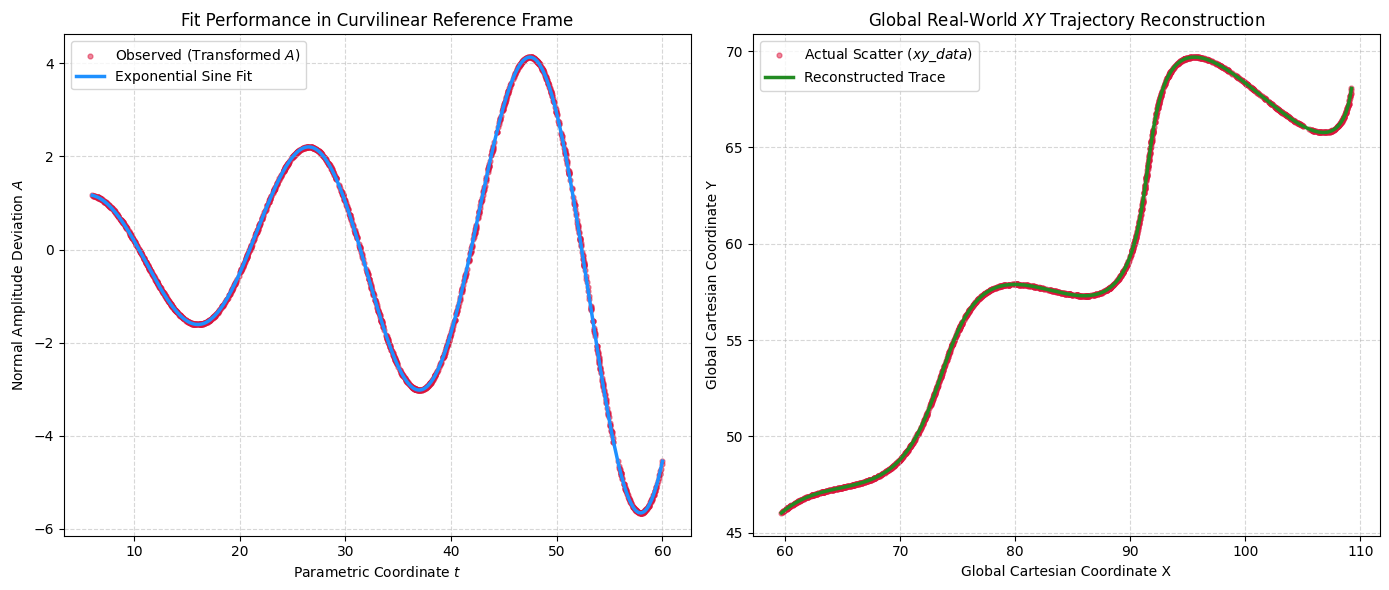

In [4]:
print("\nGenerating visual performance diagnostics...")
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
sort_idx = np.argsort(t)

# Panel 1: Curvilinear Space Fit Comparison
plt.subplot(1, 2, 1)
plt.scatter(t, A, color='crimson', alpha=0.5, s=12, label='Observed (Transformed $A$)')
plt.plot(t[sort_idx], pred[sort_idx], color='dodgerblue', linewidth=2.5, label='Exponential Sine Fit')
plt.xlabel('Parametric Coordinate $t$')
plt.ylabel('Normal Amplitude Deviation $A$')
plt.title('Fit Performance in Curvilinear Reference Frame')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Panel 2: Cartesian Global Coordinates Reconstruction
plt.subplot(1, 2, 2)
# Reconstruct predicted path in X-Y domain
x_model = X + t * np.cos(theta) - pred * np.sin(theta)
y_model = 42 + t * np.sin(theta) + pred * np.cos(theta)

plt.scatter(x, y, color='crimson', alpha=0.5, s=12, label='Actual Scatter ($xy\\_data$)')
plt.plot(x_model[sort_idx], y_model[sort_idx], color='forestgreen', linewidth=2.5, label='Reconstructed Trace')
plt.xlabel('Global Cartesian Coordinate X')
plt.ylabel('Global Cartesian Coordinate Y')
plt.title('Global Real-World $XY$ Trajectory Reconstruction')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("least_squares_diagnostic_plots.png", dpi=300)
print("Diagnostic visualization maps compiled and saved to 'least_squares_diagnostic_plots.png'")

# **Check all code below to predict the t value for each x,y pair of given dataset**
#**for training xy_data.csv**

# Remember the rule of machine learning, that rate % in improvement after certain iterations, currently matching x,y and predicted value is 688 , following code will also predict t and iterate t value to get beter t , but error will decrease in 10 power 3 times, not much decrease in error after 6 decimals.

# **Find out approximate t for each (x,y) pair from below else don't go for code below**

In [7]:
import numpy as np
import pandas as pd
from scipy.optimize import least_squares

# =====================================================
# Load data
# =====================================================


df = pd.read_csv(
    "xy_data.csv",
    dtype=str
)

# Keep original text for decimal counting
x_text = df["x"].values
y_text = df["y"].values

# Convert to float for optimization
x = x_text.astype(np.float64)
y = y_text.astype(np.float64)

print("Data points:", len(x))
print("Data points:", len(x))


# =====================================================
# Residual function in x,y space
# =====================================================

def residuals_xy(params):

    theta_deg, M, X = params

    theta = np.radians(theta_deg)

    c = np.cos(theta)
    s = np.sin(theta)

    # Transform observed points to curve coordinate
    Xp = x - X
    Yp = y - 42

    t = Xp*c + Yp*s

    # Model curve
    A = np.exp(M*np.abs(t))*np.sin(0.3*t)


    # Inverse transformation
    x_model = X + t*c - A*s
    y_model = 42 + t*s + A*c


    # Return both x and y errors
    return np.concatenate([
        x_model - x,
        y_model - y
    ])



# =====================================================
# Multiple starting points
# =====================================================

# starts = [

#     [70, 0.03, 10],

#     [0, -0.05, 0],

#     [15, 0.05, 50],

#     [25, 0.05, 50],

#     [90, 0.01, 60]

# ]
starts = [
    [5,  -0.04, 10],
    [5,   0.04, 90],
    [15, -0.02, 30],
    [25,  0.00, 50],
    [35,  0.02, 70],
    [45,  0.04, 90],
    [10,  0.03, 50],
    [40, -0.03, 50],
]

best_result = None
best_cost = np.inf


for x0 in starts:

    print("\nStarting point:", x0)

    result = least_squares(
        residuals_xy,
        x0=x0,
        method="trf",
        jac="3-point",
        x_scale="jac",
        diff_step=1e-8,
        ftol=1e-15,
        xtol=1e-15,
        gtol=1e-15,
        max_nfev=200000
    )


    cost = np.sum(result.fun**2)


    print("Cost:", cost)
    print("Parameters:", result.x)


    if cost < best_cost:
        best_cost = cost
        best_result = result



# =====================================================
# Refinement
# =====================================================

print("\nRefinement")

for i in range(20):

    best_result = least_squares(
        residuals_xy,
        x0=best_result.x,
        method="trf",
        jac="3-point",
        x_scale="jac",
        diff_step=1e-9,
        ftol=1e-15,
        xtol=1e-15,
        gtol=1e-15,
        max_nfev=200000
    )


# =====================================================
# Final parameters
# =====================================================

theta_deg, M, X = best_result.x


print("\n==============================")
print("FINAL PARAMETERS")
print("==============================")

print(f"Theta = {theta_deg:.30f}")
print(f"M     = {M:.30f}")
print(f"X     = {X:.30f}")

print("\nCost")
print("----------------")
print(f"{np.sum(best_result.fun**2):.30e}")


print("\nOptimizer information")
print("----------------")
print("Success:", best_result.success)
print("Iterations:", best_result.nfev)
print("Message:", best_result.message)



# =====================================================
# Generate reconstructed x,y
# =====================================================

theta = np.radians(theta_deg)

c = np.cos(theta)
s = np.sin(theta)


Xp = x - X
Yp = y - 42

t = Xp*c + Yp*s

A = np.exp(M*np.abs(t))*np.sin(0.3*t)


x_pred = X + t*c - A*s
y_pred = 42 + t*s + A*c



# =====================================================
# Error statistics
# =====================================================

distance_error = np.sqrt(
    (x_pred-x)**2 +
    (y_pred-y)**2
)


print("\nCoordinate Error")
print("----------------")
print("Maximum error:",
      distance_error.max())

print("Average error:",
      distance_error.mean())

print("RMS error:",
      np.sqrt(np.mean(distance_error**2)))


#....................l1 distance
l1_distance = np.sum(np.abs(x_pred - x) + np.abs(y_pred - y))
print("\n" + "#"*60)
print(f"#   TOTAL L1 DISTANCE: \033[1;31;43m  {l1_distance:<25.15f}  \033[0m #")
print("#"*60 + "\n")

# L1 Geometric Distance as Per-Point Mean Absolute Error (MAE)
l1_geometric_mae = np.mean(distance_error)

print("\n" + "█"*65)
print(f"  🚨 L1 GEOMETRIC DISTANCE (MAE): {l1_geometric_mae:.15f} 🚨")
print("█"*65 + "\n")
# ------------------------------
# =====================================================
# Ordered precision matching test
# =====================================================

def round_match(a, b, decimals):
    return np.round(a, decimals) == np.round(b, decimals)


n = len(x)

# Store original predictions permanently
x_pred_original = x_pred.copy()
y_pred_original = y_pred.copy()


x_match = np.zeros(n, dtype=bool)
y_match = np.zeros(n, dtype=bool)
xy_match = np.zeros(n, dtype=bool)


x_match_decimal = np.zeros(n, dtype=int)
y_match_decimal = np.zeros(n, dtype=int)
# =====================================================
# Detect decimal places from original CSV text
# =====================================================

def get_decimal_places(value):
    value = value.strip()

    if "." in value:
        return len(value.split(".")[1])

    return 0


x_csv_decimal = np.array([
    get_decimal_places(v)
    for v in x_text
])

y_csv_decimal = np.array([
    get_decimal_places(v)
    for v in y_text
])
# -----------------------------------------------------
# Try X precision: 6 -> 5 -> 4 -> 3
# For each X precision try Y: 6 -> 5 -> 4 -> 3
# -----------------------------------------------------
# =====================================================
# Precision matching with CSV decimal limit
# =====================================================

for x_dec in [6, 5, 4, 3]:

    for y_dec in [6, 5, 4, 3]:

        # Only XY unmatched points continue searching for XY
        remaining_idx = np.where(~xy_match)[0]

        if len(remaining_idx) == 0:
            break

        x_pred_rem = x_pred_original[remaining_idx]
        y_pred_rem = y_pred_original[remaining_idx]

        x_rem = x[remaining_idx]
        y_rem = y[remaining_idx]

        x_csv_dec_rem = x_csv_decimal[remaining_idx]
        y_csv_dec_rem = y_csv_decimal[remaining_idx]

        # Don't reduce below CSV precision
        valid_x = (x_csv_dec_rem <= x_dec)
        valid_y = (y_csv_dec_rem <= y_dec)

        # Check X
        x_ok = (
            np.round(x_pred_rem, x_dec)
            ==
            np.round(x_rem, x_dec)
        )

        # Check Y
        y_ok = (
            np.round(y_pred_rem, y_dec)
            ==
            np.round(y_rem, y_dec)
        )

        # -------------------------------------------------
        # Update X matches independently
        # -------------------------------------------------
        x_new = remaining_idx[
            valid_x &
            x_ok &
            (~x_match[remaining_idx])
        ]

        x_match[x_new] = True
        x_match_decimal[x_new] = x_dec

        # -------------------------------------------------
        # Update Y matches independently
        # -------------------------------------------------
        y_new = remaining_idx[
            valid_y &
            y_ok &
            (~y_match[remaining_idx])
        ]

        y_match[y_new] = True
        y_match_decimal[y_new] = y_dec

        # -------------------------------------------------
        # Update XY matches
        # -------------------------------------------------
        xy_new = remaining_idx[
            valid_x &
            valid_y &
            x_ok &
            y_ok
        ]

        xy_match[xy_new] = True

        # Save precision used for XY if not already saved
        x_match_decimal[xy_new] = x_dec
        y_match_decimal[xy_new] = y_dec

print("X matched :", np.sum(x_match))
print("Y matched :", np.sum(y_match))
print("XY matched:", np.sum(xy_match))
print("\nOrdered precision match")
print("----------------------")

print("Total points:",
      n)

print("XY matched:",
      np.sum(xy_match))

print("Percentage:",
      np.sum(xy_match)/n*100)



print("\nPrecision used")
print("----------------------")

print("X precision:")
print(
    np.unique(
        x_match_decimal[xy_match],
        return_counts=True
    )
)


print("Y precision:")
print(
    np.unique(
        y_match_decimal[xy_match],
        return_counts=True
    )
)

# =====================================================
# Create Excel report
# =====================================================

report = pd.DataFrame({

    "Original_X": x,
    "Original_Y": y,

    "Predicted_X": x_pred,
    "Predicted_Y": y_pred,

    "Rounded_Predicted_X": [
        round(x_pred[i], int(x_match_decimal[i]))
        if x_match_decimal[i] > 0
        else np.nan
        for i in range(len(x))
    ],

    "Rounded_Predicted_Y": [
        round(y_pred[i], int(y_match_decimal[i]))
        if y_match_decimal[i] > 0
        else np.nan
        for i in range(len(y))
    ],

    "X_match_decimal": x_match_decimal,
    "Y_match_decimal": y_match_decimal,

    "X_match": x_match,
    "Y_match": y_match,
    "XY_match": xy_match,

    "t": t,

    "X_error": x_pred - x,
    "Y_error": y_pred - y,

    "Distance_error": distance_error

})


matched_df = report[
    report["XY_match"] == True
]


unmatched_df = report[
    report["XY_match"] == False
]


output_file = "model_precision_matching.xlsx"


with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    matched_df.to_excel(
        writer,
        sheet_name="Matched",
        index=False
    )

    unmatched_df.to_excel(
        writer,
        sheet_name="Unmatched",
        index=False
    )

    report.to_excel(
        writer,
        sheet_name="All_Data",
        index=False
    )


print("\nExcel created")
print("----------------")
print(output_file)

print("Matched rows:",
      len(matched_df))

print("Unmatched rows:",
      len(unmatched_df))

Data points: 1500
Data points: 1500

Starting point: [5, -0.04, 10]
Cost: 1.8229979358410254e-08
Parameters: [2.99999729e+01 2.99999969e-02 5.49999982e+01]

Starting point: [5, 0.04, 90]
Cost: 1.8229979361467176e-08
Parameters: [2.99999729e+01 2.99999969e-02 5.49999982e+01]

Starting point: [15, -0.02, 30]
Cost: 13594.36822452381
Parameters: [1.87861597e+01 1.76064148e-02 3.28065001e+01]

Starting point: [25, 0.0, 50]
Cost: 1.822997936241048e-08
Parameters: [2.99999729e+01 2.99999969e-02 5.49999982e+01]

Starting point: [35, 0.02, 70]
Cost: 1.822997936012422e-08
Parameters: [2.99999729e+01 2.99999969e-02 5.49999982e+01]

Starting point: [45, 0.04, 90]
Cost: 1.8229979360625477e-08
Parameters: [2.99999729e+01 2.99999969e-02 5.49999982e+01]

Starting point: [10, 0.03, 50]
Cost: 1.8229979360966394e-08
Parameters: [2.99999729e+01 2.99999969e-02 5.49999982e+01]

Starting point: [40, -0.03, 50]
Cost: 1.8229979358460834e-08
Parameters: [2.99999729e+01 2.99999969e-02 5.49999982e+01]

Refinement

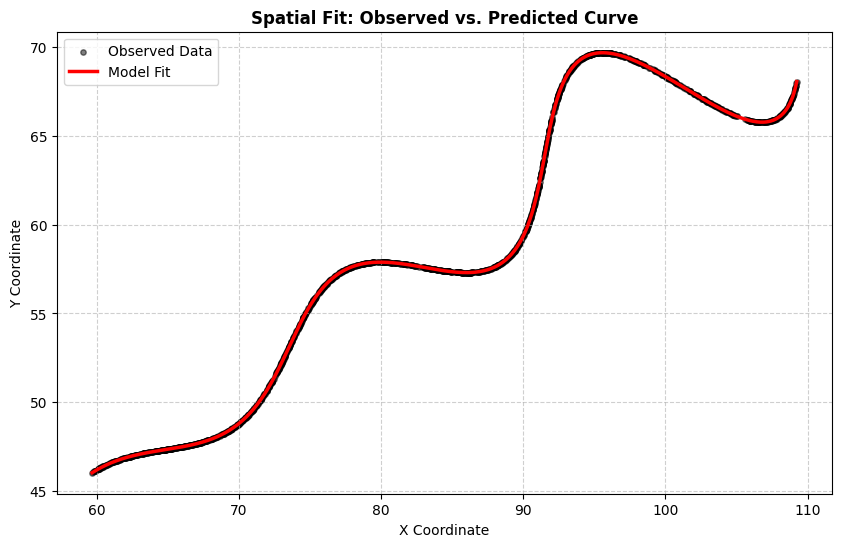

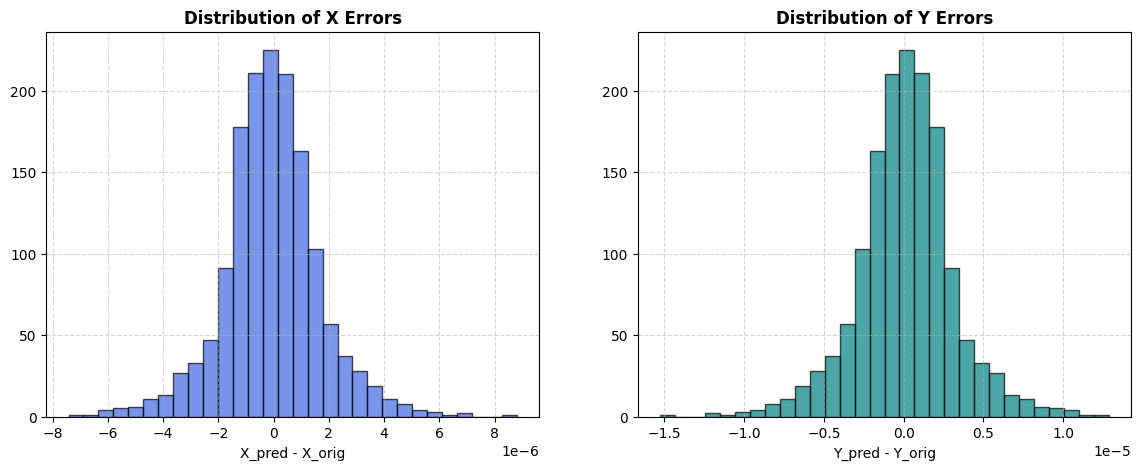

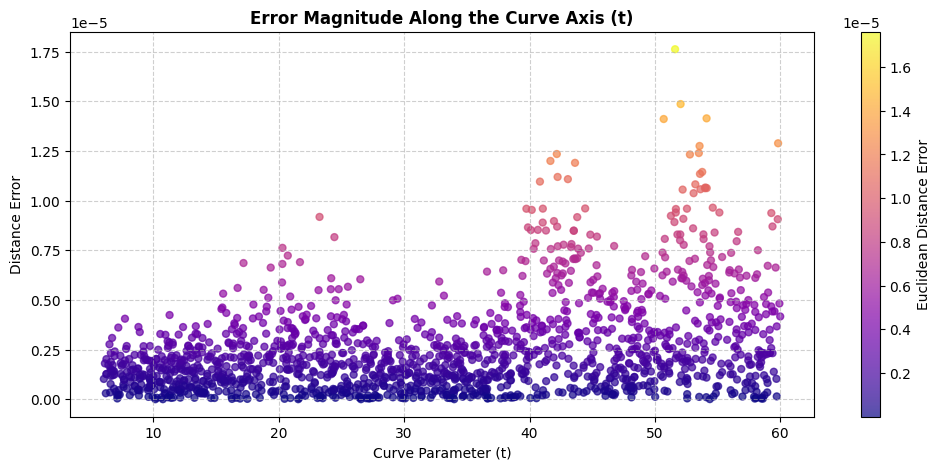

In [6]:
# =====================================================
# Plots Generation
# =====================================================
import matplotlib.pyplot as plt

# 1. Curve Fit Plot (Observed vs Predicted)
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color="black", alpha=0.5, label="Observed Data", s=15)
sort_idx = np.argsort(t)
plt.plot(x_pred[sort_idx], y_pred[sort_idx], color="red", linewidth=2.5, label="Model Fit")
plt.title("Spatial Fit: Observed vs. Predicted Curve", fontsize=12, fontweight="bold")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig("plot_curve_fit.png", dpi=300)
plt.show()

# 2. Residual Distribution Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(report["X_error"], bins=30, color="royalblue", edgecolor="black", alpha=0.7)
axes[0].set_title("Distribution of X Errors", fontweight="bold")
axes[0].set_xlabel("X_pred - X_orig")
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].hist(report["Y_error"], bins=30, color="teal", edgecolor="black", alpha=0.7)
axes[1].set_title("Distribution of Y Errors", fontweight="bold")
axes[1].set_xlabel("Y_pred - Y_orig")
axes[1].grid(True, linestyle="--", alpha=0.5)
plt.savefig("plot_residuals.png", dpi=300)
plt.show()

# 3. Error Profile Along Curve Parameter t
plt.figure(figsize=(12, 5))
sc = plt.scatter(t, distance_error, c=distance_error, cmap="plasma", alpha=0.7, s=25)
plt.colorbar(sc, label="Euclidean Distance Error")
plt.title("Error Magnitude Along the Curve Axis (t)", fontsize=12, fontweight="bold")
plt.xlabel("Curve Parameter (t)")
plt.ylabel("Distance Error")
plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig("plot_error_along_t.png", dpi=300)
plt.show()

# **Optimize above t values to most accurate t and then find difference between x_data and y _data to *upto*   6 decimal values of x and y predicted **

Input for below code is new_data_(1) , download that csv file from github repo. or just manually keep above t values in original data xy_data.csv after adding a column.

't' column already exists in xy_data.csv. Proceeding directly to pipeline.
Loaded 1500 rows.
Stage 1: Differential Evolution global search...
  Stage 1 result: theta=29.999973 deg, M=0.030000, X=54.999998

Stage 2 (outer iter 1): local joint refinement...
  theta=29.999972989682927249077692977152764797210693359375000000000000 deg, M=0.029999997152038260922468637659221712965518236160278320312500, X=54.999998327074273163361795013770461082458496093750000000000000, cost=5.468712975640753072e-09, nfev=3
  Param change vs previous outer iter: 3.548e-09
  Converged (param change below tolerance).

=========== FINAL RESULTS ===========
theta (deg) = 29.999972989693731051374925300478935241699218750000000000000000
M           = 0.029999997152141077982889783015707507729530334472656250000000
X           = 54.999998327135344311500375624746084213256835937500000000000000

█████████████████████████████████████████████████████████████████
🚨 Mean L1 Dist= 2.659972e-06
Max L1 Dist = 1.371488e-05
████████

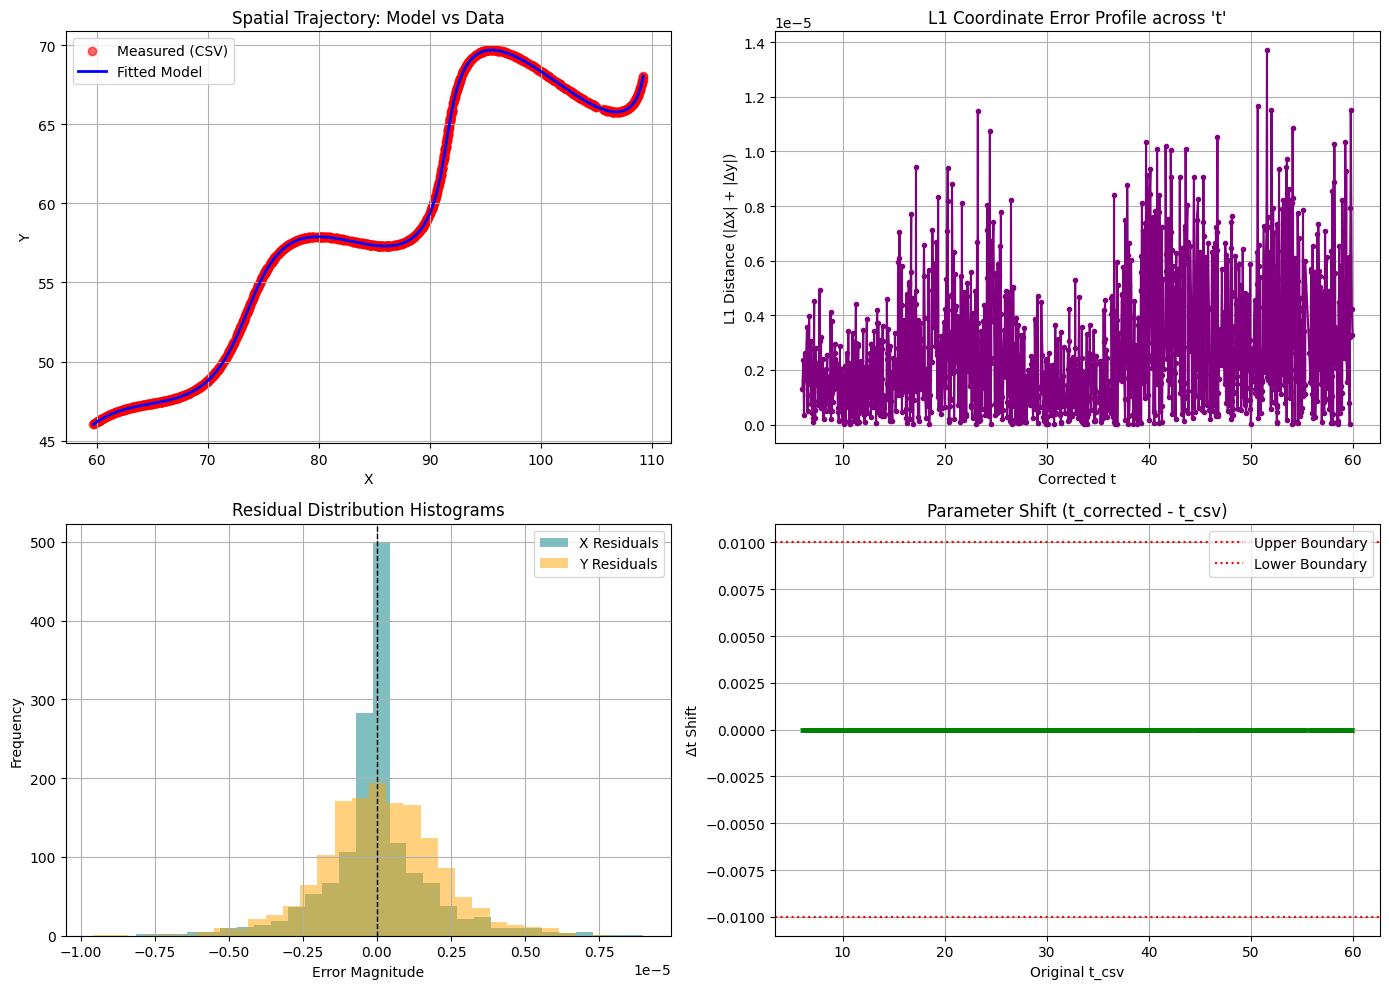

Saved comprehensive diagnostic layout to 'optimization_diagnostic_plots.png'
Successfully updated 'xy_data.csv' with refined 't' values.


In [25]:
# =====================================================
# Pre-check/Initialize t in xy_data.csv
# =====================================================
df_orig = pd.read_csv("xy_data.csv")

if "t" in df_orig.columns:
    print("'t' column already exists in xy_data.csv. Proceeding directly to pipeline.")
else:
    print("'t' column missing. Initializing from best_result parameters...")
    # Extract best parameters found during the multi-start/refinement phases
    theta_deg, M, X = best_result.x
    theta = np.radians(theta_deg)

    # Calculate initial projection parameter 't'
    Xp = df_orig["x"].values.astype(np.float64) - X
    Yp = df_orig["y"].values.astype(np.float64) - 42
    t_calculated = Xp * np.cos(theta) + Yp * np.sin(theta)

    # Add and sort by t to ensure monotonic alignment for Stage 2
    df_orig["t"] = t_calculated
    df_orig = df_orig.sort_values(by="t", ascending=True).reset_index(drop=True)
    df_orig.to_csv("xy_data.csv", index=False)
    print("Initialized and saved sorted 't' column to xy_data.csv.")
"""
Recover global parameters (theta, M, X) and per-row corrected t values from
data.csv, given the model:

    x = t*cos(theta) - sin(theta)*sin(0.3*t)*exp(M*|t|) + X
    y = t*sin(theta) - cos(theta)*sin(0.3*t)*exp(M*|t|) + 42

Pipeline:
  Stage 1: Differential Evolution over (theta, M, X) with t fixed to t_csv.
  Stage 2: Large-scale sparse nonlinear least-squares over
           (theta, M, X, t_1..t_N) jointly, t_i bounded tightly around
           t_csv_i (which, combined with sorted/well-separated t_csv,
           enforces the monotonic ordering constraint).
  Stage 3: Safety enforcement of strict monotonicity (np.maximum.accumulate
           style) in case bounds ever touch/overlap.
  Stage 4: Alternate Stage 1 (re-seed) / Stage 2 (refine) until parameter
           changes fall below tolerance.

Outputs:
  - Printed estimates of theta, M, X
  - results.csv  : t_corrected, x_pred, y_pred, x_csv, y_csv, resid_x, resid_y
  - summary printed: RMSE, max abs error
"""

import numpy as np
import pandas as pd
from scipy.optimize import differential_evolution, least_squares
from scipy.sparse import lil_matrix

# ----------------------------------------------------------------------
# CONFIG
# ----------------------------------------------------------------------
CSV_PATH = "xy_data.csv"
OUT_PATH = "results.csv"

LAMBDA = 1.0          # weight on (t_i - t_csv_i)^2 regularization term
T_TOL = 0.01           # allowed deviation of corrected t from measured t
                       # (tune this to your data's t spacing; must be smaller
                       # than ~half the minimum gap between consecutive t_csv
                       # values so bounds alone preserve monotonic order)

THETA_BOUNDS = (0.0, 50.0)      # degrees
M_BOUNDS = (-0.05, 0.05)
X_BOUNDS = (0.0, 100.0)

MAX_OUTER_ITERS = 5             # Stage 4 outer iterations
OUTER_TOL = 1e-8                # stop when param vector change < this


# ----------------------------------------------------------------------
# MODEL
# ----------------------------------------------------------------------
def model(t, theta_deg, M, X):
    theta = np.radians(theta_deg)
    e = np.exp(M * np.abs(t))
    s = np.sin(0.3 * t)
    x = t * np.cos(theta) - np.sin(theta) * s * e + X
    y = t * np.sin(theta) + np.cos(theta) * s * e + 42.0
    return x, y


# ----------------------------------------------------------------------
# STAGE 1: Differential Evolution over (theta, M, X), t fixed
# ----------------------------------------------------------------------
def stage1_global_search(t_csv, x_csv, y_csv, seed=0):
    def objective(params):
        theta, M, X = params
        x_pred, y_pred = model(t_csv, theta, M, X)
        return np.sum((x_pred - x_csv) ** 2 + (y_pred - y_csv) ** 2)

    bounds = [THETA_BOUNDS, M_BOUNDS, X_BOUNDS]
    result = differential_evolution(
        objective,
        bounds,
        seed=seed,
        maxiter=300,
        popsize=25,
        tol=1e-12,
        mutation=(0.4, 1.5),
        recombination=0.8,
        polish=True,
        updating="deferred",
        workers=1,
    )
    return result.x  # theta, M, X


# ----------------------------------------------------------------------
# STAGE 2: Joint sparse nonlinear least-squares over theta, M, X, t_1..t_N
# ----------------------------------------------------------------------
def build_sparsity(n):
    """Rows: [res_x (n), res_y (n), res_t (n)]  Cols: [theta, M, X, t_1..t_n]"""
    n_rows = 3 * n
    n_cols = 3 + n
    J = lil_matrix((n_rows, n_cols), dtype=int)
    idx = np.arange(n)
    # res_x rows depend on theta,M,X and their own t_i
    J[idx, 0] = 1
    J[idx, 1] = 1
    J[idx, 2] = 1
    J[idx, 3 + idx] = 1
    # res_y rows
    J[n + idx, 0] = 1
    J[n + idx, 1] = 1
    J[n + idx, 2] = 1
    J[n + idx, 3 + idx] = 1
    # res_t (regularization) rows depend only on own t_i
    J[2 * n + idx, 3 + idx] = 1
    return J.tocsr()


def stage2_local_refine(t_csv, x_csv, y_csv, theta0, M0, X0, t_tol=T_TOL, lam=LAMBDA):
    n = len(t_csv)
    sqrt_lam = np.sqrt(lam)

    def residuals(params):
        theta, M, X = params[0], params[1], params[2]
        t = params[3:]
        x_pred, y_pred = model(t, theta, M, X)
        res_x = x_pred - x_csv
        res_y = y_pred - y_csv
        res_t = sqrt_lam * (t - t_csv)
        return np.concatenate([res_x, res_y, res_t])

    x0 = np.concatenate([[theta0, M0, X0], t_csv.copy()])

    lower = np.concatenate([
        [THETA_BOUNDS[0], M_BOUNDS[0], X_BOUNDS[0]],
        t_csv - t_tol
    ])
    upper = np.concatenate([
        [THETA_BOUNDS[1], M_BOUNDS[1], X_BOUNDS[1]],
        t_csv + t_tol
    ])
    # keep x0 strictly inside bounds
    x0 = np.clip(x0, lower + 1e-12, upper - 1e-12)

    sparsity = build_sparsity(n)

    result = least_squares(
        residuals,
        x0,
        jac="2-point",
        jac_sparsity=sparsity,
        bounds=(lower, upper),
        method="trf",
        xtol=1e-12,
        ftol=1e-12,
        gtol=1e-12,
        max_nfev=2000,
        verbose=0,
    )
    theta, M, X = result.x[0], result.x[1], result.x[2]
    t_corrected = result.x[3:]
    return theta, M, X, t_corrected, result


# ----------------------------------------------------------------------
# STAGE 3: enforce strict monotonicity as a safety net
# ----------------------------------------------------------------------
def enforce_monotonic(t):
    t = t.copy()
    eps = 1e-9
    for i in range(1, len(t)):
        if t[i] <= t[i - 1]:
            t[i] = t[i - 1] + eps
    return t


# ----------------------------------------------------------------------
# STAGE 4: outer iteration
# ----------------------------------------------------------------------
def run_pipeline(csv_path=CSV_PATH, out_path=OUT_PATH):
    df = pd.read_csv(csv_path)
    x_csv = df["x"].to_numpy(dtype=float)
    y_csv = df["y"].to_numpy(dtype=float)
    t_csv = df["t"].to_numpy(dtype=float)
    n = len(df)

    # sanity: ensure sorted; if not, sort by t (and keep original order info)
    if not np.all(np.diff(t_csv) > 0):
        order = np.argsort(t_csv)
        t_csv, x_csv, y_csv = t_csv[order], x_csv[order], y_csv[order]

    print(f"Loaded {n} rows.")

    # ---------------- Stage 1 ----------------
    print("Stage 1: Differential Evolution global search...")
    theta, M, X = stage1_global_search(t_csv, x_csv, y_csv)
    print(f"  Stage 1 result: theta={theta:.6f} deg, M={M:.6f}, X={X:.6f}")

    t_current = t_csv.copy()
    prev_params = np.array([theta, M, X])

    for outer in range(1, MAX_OUTER_ITERS + 1):
        print(f"\nStage 2 (outer iter {outer}): local joint refinement...")
        theta, M, X, t_current, res = stage2_local_refine(
            t_csv, x_csv, y_csv, theta, M, X, t_tol=T_TOL, lam=LAMBDA
        )
        print(f"  theta={theta:.60f} deg, M={M:.60f}, X={X:.60f}, "
              f"cost={res.cost:.18e}, nfev={res.nfev}")

        # Stage 3: monotonic safety net
        t_current = enforce_monotonic(t_current)

        # Stage 1 re-seed using refined t (helps escape local minima)
        theta2, M2, X2 = stage1_global_search(t_current, x_csv, y_csv, seed=outer)
        cur_cost = np.sum(
            (np.array(model(t_current, theta, M, X)) -
             np.array([x_csv, y_csv])) ** 2
        )
        new_cost = np.sum(
            (np.array(model(t_current, theta2, M2, X2)) -
             np.array([x_csv, y_csv])) ** 2
        )
        if new_cost < cur_cost:
            theta, M, X = theta2, M2, X2

        new_params = np.array([theta, M, X])
        change = np.max(np.abs(new_params - prev_params))
        print(f"  Param change vs previous outer iter: {change:.3e}")
        prev_params = new_params
        if change < OUTER_TOL:
            print("  Converged (param change below tolerance).")
            break

    # ---------------- Final predictions & diagnostics ----------------
    x_pred, y_pred = model(t_current, theta, M, X)
    resid_x = x_pred - x_csv
    resid_y = y_pred - y_csv
    resid_t = t_current - t_csv

    rmse = np.sqrt(np.mean(resid_x ** 2 + resid_y ** 2))
    max_abs_err = np.max(np.abs(np.concatenate([resid_x, resid_y])))

    print("\n=========== FINAL RESULTS ===========")
    print(f"theta (deg) = {theta:.60f}")
    print(f"M           = {M:.60f}")
    print(f"X           = {X:.60f}")

    # Accurate L1 Distance calculation: sum of absolute errors for each point
    l1_distances = np.abs(resid_x) + np.abs(resid_y)
    mean_l1_dist = np.mean(l1_distances)
    max_l1_dist = np.max(l1_distances)

    print("\n" + "█"*65)

    print(f"🚨 Mean L1 Dist= {mean_l1_dist:.6e}")
    print(f"Max L1 Dist = {max_l1_dist:.6e}")

    print("█"*65 + "\n")
    print(f"RMSE (x,y)  = {rmse:.6e}")
    print(f"Max |error| = {max_abs_err:.6e}")
    print(f"Max |t correction| = {np.max(np.abs(resid_t)):.6e}")
    print(f"Monotonic t_current: {np.all(np.diff(t_current) > 0)}")

    out = pd.DataFrame({
        "t_csv": t_csv,
        "t_corrected": t_current,
        "x_csv": x_csv,
        "y_csv": y_csv,
        "x_pred": x_pred,
        "y_pred": y_pred,
        "resid_x": resid_x,
        "resid_y": resid_y,
        "resid_t": resid_t,
    })
    out.to_csv(out_path, index=False)
    print(f"\nSaved detailed results to {out_path}")

    # ----------------------------------------------------------------------
    # PLOTTING PIPELINE
    # ----------------------------------------------------------------------
    import matplotlib.pyplot as plt

    fig, axs = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Trajectory Mapping (Spatial Overlay)
    axs[0, 0].scatter(x_csv, y_csv, color="red", alpha=0.6, label="Measured (CSV)")
    axs[0, 0].plot(x_pred, y_pred, color="blue", linewidth=2, label="Fitted Model")
    axs[0, 0].set_title("Spatial Trajectory: Model vs Data")
    axs[0, 0].set_xlabel("X")
    axs[0, 0].set_ylabel("Y")
    axs[0, 0].legend()
    axs[0, 0].grid(True)

    # Plot 2: Absolute L1 Error Profile over Parameter t
    axs[0, 1].plot(t_current, l1_distances, color="purple", marker="o", markersize=3, linestyle="-")
    axs[0, 1].set_title("L1 Coordinate Error Profile across 't'")
    axs[0, 1].set_xlabel("Corrected t")
    axs[0, 1].set_ylabel("L1 Distance (|Δx| + |Δy|)")
    axs[0, 1].grid(True)

    # Plot 3: Residual Histograms
    axs[1, 0].hist(resid_x, bins=30, alpha=0.5, label="X Residuals", color="teal")
    axs[1, 0].hist(resid_y, bins=30, alpha=0.5, label="Y Residuals", color="orange")
    axs[1, 0].axvline(0, color="black", linestyle="--", linewidth=1)
    axs[1, 0].set_title("Residual Distribution Histograms")
    axs[1, 0].set_xlabel("Error Magnitude")
    axs[1, 0].set_ylabel("Frequency")
    axs[1, 0].legend()
    axs[1, 0].grid(True)

    # Plot 4: Optimization Correction Profile (t_corrected - t_csv)
    axs[1, 1].plot(t_csv, resid_t, color="green", marker="x", markersize=3)
    axs[1, 1].axhline(T_TOL, color="red", linestyle=":", label="Upper Boundary")
    axs[1, 1].axhline(-T_TOL, color="red", linestyle=":", label="Lower Boundary")
    axs[1, 1].set_title("Parameter Shift (t_corrected - t_csv)")
    axs[1, 1].set_xlabel("Original t_csv")
    axs[1, 1].set_ylabel("Δt Shift")
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.savefig("optimization_diagnostic_plots.png", dpi=300)
    plt.show()
    print("Saved comprehensive diagnostic layout to 'optimization_diagnostic_plots.png'")

    # ----------------------------------------------------------------------
    # Overwrite the original input file with the newly corrected t values
    # ----------------------------------------------------------------------
    df_updated = pd.DataFrame({
        "x": x_csv,
        "y": y_csv,
        "t": t_current
    })
    df_updated.to_csv(csv_path, index=False)
    print(f"Successfully updated '{csv_path}' with refined 't' values.")
    # ----------------------------------------------------------------------

    return {
        "theta": theta, "M": M, "X": X,
        "t_corrected": t_current,
        "x_pred": x_pred, "y_pred": y_pred,
        "rmse": rmse, "max_abs_err": max_abs_err,
        "results_df": out,
    }





if __name__ == "__main__":
    run_pipeline()

If you will iterate above csv t value and again give as input, more x_predicted will be much near to x_csv.

**Don't iterate more than 4 times elsse it will overfit** the number fours just came from multiple experiment by me.

In [26]:
"""
Check whether x_pred matches x_csv (and y_pred matches y_csv) at the SAME
decimal precision each csv value was originally rounded to (3-6 digits,
varies row by row).

Requires:
  - data.csv        : original file with columns x, y, t   (string precision matters)
  - results.csv      : produced by solve_params.py, has t_corrected, x_pred, y_pred
                        (or supply your own x_pred / y_pred arrays)

Adds 3 new columns to a fresh output csv:
  - x_match  (bool)
  - y_match  (bool)
  - xy_match (bool)   -> True only if BOTH x_match and y_match are True

Also prints individual true counts.
"""

import numpy as np
import pandas as pd


def decimal_places(value_str):
    """Number of digits after the decimal point in the original string.
    Trailing zeros are NOT stripped -- they are part of the stored precision
    (e.g. '46.320000' means 6 decimal digits were stored, not 2)."""
    s = str(value_str).strip()
    if "." in s:
        return len(s.split(".")[1])
    return 0


def check_matches(data_csv_path="xy_data.csv", results_csv_path="results.csv",
                   out_path="match_results.csv"):
    # Read original file as strings to preserve exact rounding precision
    raw = pd.read_csv(data_csv_path, dtype=str)
    x_csv_str = raw["x"].str.strip()
    y_csv_str = raw["y"].str.strip()

    x_csv = x_csv_str.astype(float).to_numpy()
    y_csv = y_csv_str.astype(float).to_numpy()

    # decimal precision used for each row's x and y (independently, since
    # x and y need not share the same rounding)
    x_decimals = x_csv_str.apply(decimal_places).to_numpy()
    y_decimals = y_csv_str.apply(decimal_places).to_numpy()

    # Predicted values (from results.csv produced by solve_params.py)
    res = pd.read_csv(results_csv_path)
    x_pred = res["x_pred"].to_numpy()
    y_pred = res["y_pred"].to_numpy()


    n = len(x_csv)
    x_match = np.zeros(n, dtype=bool)
    y_match = np.zeros(n, dtype=bool)
    x_pred_rounded = np.empty(n, dtype=object)
    y_pred_rounded = np.empty(n, dtype=object)


    for i in range(n):
        nx, ny = int(x_decimals[i]), int(y_decimals[i])
        # Round predicted value to the SAME number of decimals as the csv
        # value, then compare as formatted strings -> exact, no tolerance
        # needed and no ambiguity from binary floating-point representation.
        x_pred_str = f"{x_pred[i]:.{nx}f}"
        x_pred_rounded[i] = f"{x_pred[i]:.{nx}f}"
        x_csv_str_fmt = f"{x_csv[i]:.{nx}f}"
        x_match[i] = (x_pred_str == x_csv_str_fmt)

        y_pred_str = f"{y_pred[i]:.{ny}f}"
        y_pred_rounded[i] = f"{y_pred[i]:.{ny}f}"
        y_csv_str_fmt = f"{y_csv[i]:.{ny}f}"
        y_match[i] = (y_pred_str == y_csv_str_fmt)

    xy_match = x_match & y_match

    x_rounded_floats = x_pred_rounded.astype(float)
    y_rounded_floats = y_pred_rounded.astype(float)

    # Calculate accurate L1 distance (Manhattan distance) between raw prediction and CSV
    l1_distances = np.abs(x_csv - x_pred) + np.abs(y_csv - y_pred)

    out = res.copy()
    out["x_pred_rounded"] = x_pred_rounded
    out["y_pred_rounded"] = y_pred_rounded
    out["x_match"] = x_match
    out["y_match"] = y_match
    out["xy_match"] = xy_match
    out["l1_distance"] = l1_distances
    out["difference_sq"] = ((x_csv - x_rounded_floats) ** 2) + ((y_csv - y_rounded_floats) ** 2)

    rmse_value = np.sqrt(out["difference_sq"].mean())
    out.loc['RMSE', 'difference_sq'] = rmse_value
    # print(out.tail())
    out.to_csv(out_path, index=False)

    x_true_count = int(x_match.sum())
    y_true_count = int(y_match.sum())
    xy_true_count = int(xy_match.sum())



    print(f"Total rows            : {n}")
    print(f"x_match  True count   : {x_true_count} / {n}")
    print(f"y_match  True count   : {y_true_count} / {n}")
    print(f"xy_match True count   : {xy_true_count} / {n}")
    mean_l1_value = l1_distances.mean()
    print("\n" + "█"*65)
    print(f"Mean L1 Distance      : {mean_l1_value}")
    print("█"*65 + "\n")
    print(f"RMSE: {rmse_value}")
    print(f"\nSaved: {out_path}")

    return out, x_true_count, y_true_count, xy_true_count


if __name__ == "__main__":
    check_matches()




Total rows            : 1500
x_match  True count   : 1288 / 1500
y_match  True count   : 908 / 1500
xy_match True count   : 795 / 1500

█████████████████████████████████████████████████████████████████
Mean L1 Distance      : 2.659972029457928e-06
█████████████████████████████████████████████████████████████████

RMSE: 2.547024407625988e-06

Saved: match_results.csv


/tmp/ipykernel_3622/2616510434.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0, 0].set_xticklabels(labels, rotation=15, ha="right")


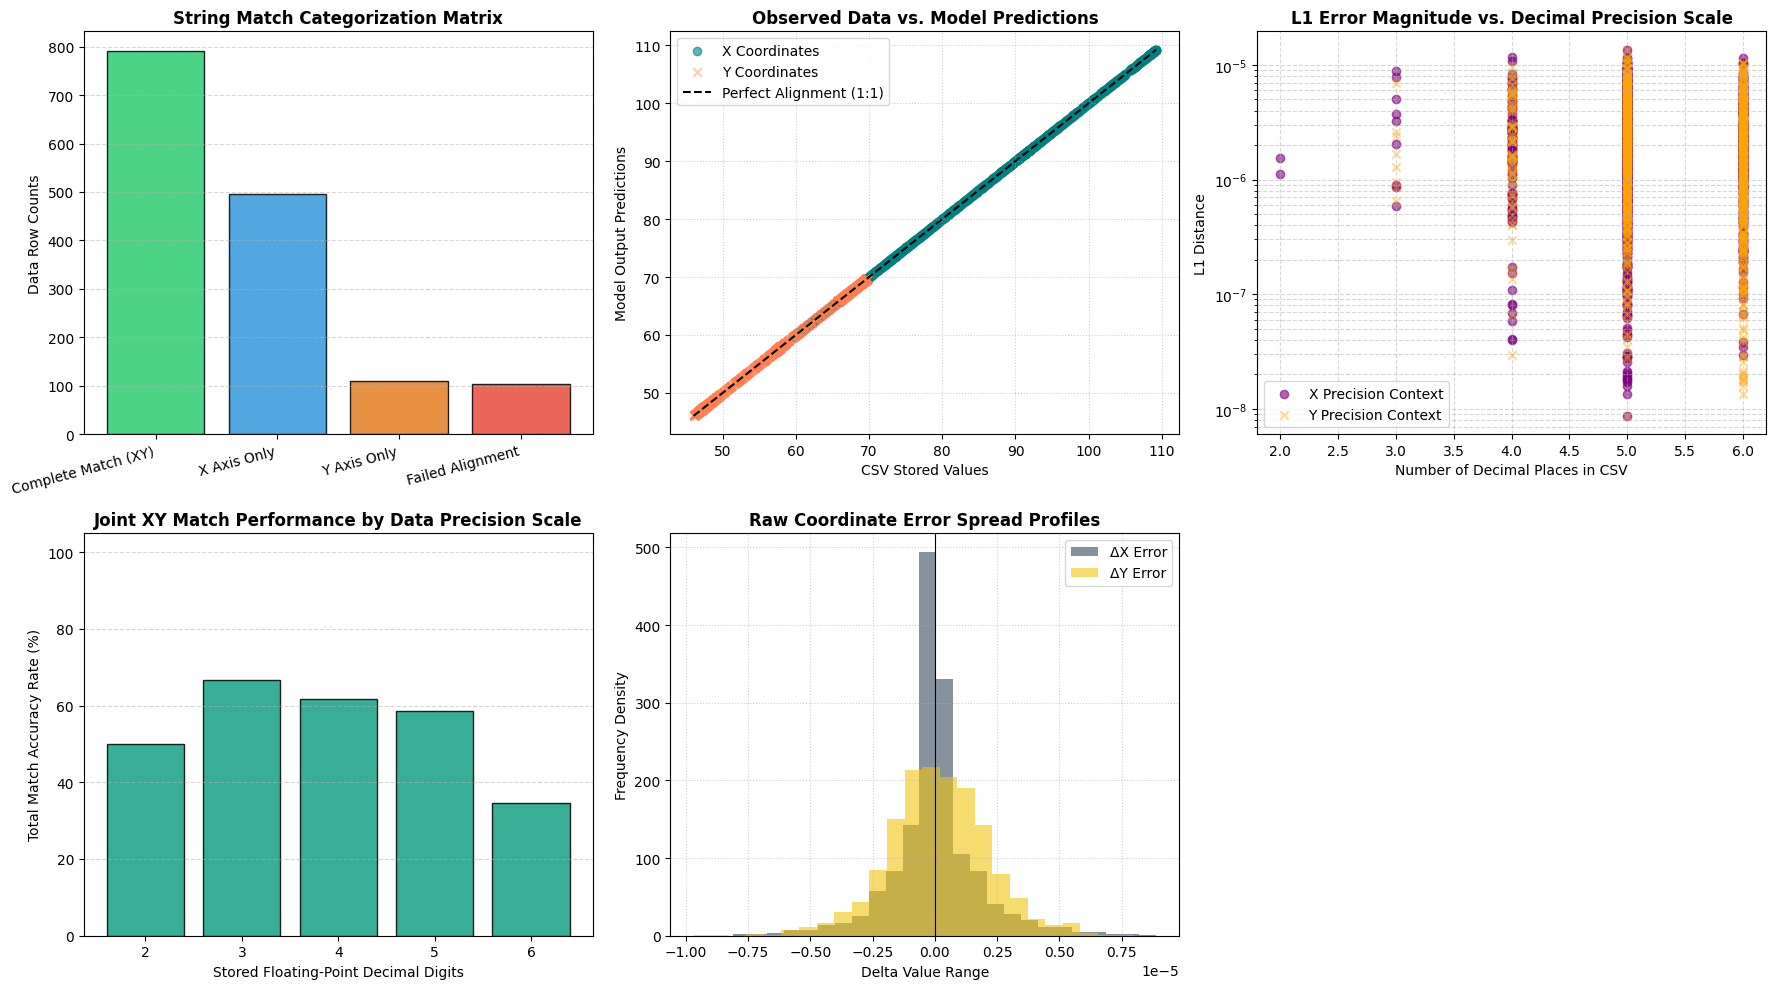

[Graphics Engine] Generated clean balanced diagnostic plots layout at 'precision_matching_diagnostics.png'


In [20]:
# Place this in a fresh line or cell directly beneath your execution line:
# out_df, x_cnt, y_cnt, xy_cnt = check_matches()

# ======================================================================
# STANDALONE PRECISION & FIT DIAGNOSTIC PLOTS
# ======================================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load clean generated results (dropping structural summary rows if appended at tail)
plot_df = pd.read_csv("match_results.csv")
plot_df = plot_df[plot_df["x_csv"].notna()]
n_points = len(plot_df)

# Reconstruct match conditions dynamically from saved columns
x_match_arr = plot_df["x_match"].to_numpy(dtype=bool)
y_match_arr = plot_df["y_match"].to_numpy(dtype=bool)
xy_match_arr = plot_df["xy_match"].to_numpy(dtype=bool)

# Safely reconstruct L1 values from coordinate residuals
l1_dist_arr = plot_df["l1_distance"].to_numpy(dtype=float) if "l1_distance" in plot_df.columns else np.abs(plot_df["x_pred"] - plot_df["x_csv"]) + np.abs(plot_df["y_pred"] - plot_df["y_csv"])

# Dynamically calculate the original decimal precision scale per row
x_prec_len = plot_df["x_csv"].astype(str).str.strip().apply(lambda s: len(s.split(".")[1]) if "." in s else 0).to_numpy()
y_prec_len = plot_df["y_csv"].astype(str).str.strip().apply(lambda s: len(s.split(".")[1]) if "." in s else 0).to_numpy()

# Initialize Canvas Layout (2 rows, 3 columns)
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Match Breakdown Categorization Matrix
labels = ['Complete Match (XY)', 'X Axis Only', 'Y Axis Only', 'Failed Alignment']
counts = [
    np.sum(x_match_arr & y_match_arr),
    np.sum(x_match_arr & ~y_match_arr),
    np.sum(~x_match_arr & y_match_arr),
    np.sum(~x_match_arr & ~y_match_arr)
]
axs[0, 0].bar(labels, counts, color=['#2ecc71', '#3498db', '#e67e22', '#e74c3c'], edgecolor='black', alpha=0.85)
axs[0, 0].set_title("String Match Categorization Matrix", fontsize=12, fontweight='bold')
axs[0, 0].set_ylabel("Data Row Counts")
axs[0, 0].grid(axis='y', linestyle='--', alpha=0.5)
# Rotates x-axis labels to avoid crowding in smaller grid layouts
axs[0, 0].set_xticklabels(labels, rotation=15, ha="right")

# Plot 2: Observed vs. Predicted Regression Alignment
axs[0, 1].scatter(plot_df["x_csv"], plot_df["x_pred"], color='teal', alpha=0.6, label='X Coordinates', marker='o')
axs[0, 1].scatter(plot_df["y_csv"], plot_df["y_pred"], color='coral', alpha=0.4, label='Y Coordinates', marker='x')
# Identity line mapping perfect fits
min_val = min(plot_df["x_csv"].min(), plot_df["y_csv"].min())
max_val = max(plot_df["x_csv"].max(), plot_df["y_csv"].max())
axs[0, 1].plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=1.5, label='Perfect Alignment (1:1)')
axs[0, 1].set_title("Observed Data vs. Model Predictions", fontsize=12, fontweight='bold')
axs[0, 1].set_xlabel("CSV Stored Values")
axs[0, 1].set_ylabel("Model Output Predictions")
axs[0, 1].legend(loc="upper left")
axs[0, 1].grid(True, linestyle=':', alpha=0.6)

# Plot 3: L1 Distance error vs Original Row Precision (Log Scale)
axs[0, 2].scatter(x_prec_len, l1_dist_arr, alpha=0.6, color='purple', label='X Precision Context')
axs[0, 2].scatter(y_prec_len, l1_dist_arr, alpha=0.4, color='orange', marker='x', label='Y Precision Context')
axs[0, 2].set_title("L1 Error Magnitude vs. Decimal Precision Scale", fontsize=12, fontweight='bold')
axs[0, 2].set_xlabel("Number of Decimal Places in CSV")
axs[0, 2].set_ylabel("L1 Distance")
axs[0, 2].set_yscale('log')
axs[0, 2].legend()
axs[0, 2].grid(True, which="both", ls="--", alpha=0.5)

# Plot 4: Success Rate Profiling across Stored Precision Scales
unique_precisions = np.unique(x_prec_len)
success_rates = [np.mean(xy_match_arr[x_prec_len == p]) * 100 for p in unique_precisions]
axs[1, 0].bar(unique_precisions.astype(str), success_rates, color='#16a085', edgecolor='black', alpha=0.85)
axs[1, 0].set_title("Joint XY Match Performance by Data Precision Scale", fontsize=12, fontweight='bold')
axs[1, 0].set_xlabel("Stored Floating-Point Decimal Digits")
axs[1, 0].set_ylabel("Total Match Accuracy Rate (%)")
axs[1, 0].set_ylim(0, 105)
axs[1, 0].grid(axis='y', linestyle='--', alpha=0.5)

# Plot 5: Precision-Matched Error Residual Distributions (Pred - CSV)
res_x = plot_df["x_pred"].to_numpy(dtype=float) - plot_df["x_csv"].to_numpy(dtype=float)
res_y = plot_df["y_pred"].to_numpy(dtype=float) - plot_df["y_csv"].to_numpy(dtype=float)
axs[1, 1].hist(res_x, bins=25, alpha=0.6, label='ΔX Error', color='#34495e')
axs[1, 1].hist(res_y, bins=25, alpha=0.6, label='ΔY Error', color='#f1c40f')
axs[1, 1].axvline(0, color='black', linestyle='-', linewidth=0.8)
axs[1, 1].set_title("Raw Coordinate Error Spread Profiles", fontsize=12, fontweight='bold')
axs[1, 1].set_xlabel("Delta Value Range")
axs[1, 1].set_ylabel("Frequency Density")
axs[1, 1].legend()
axs[1, 1].grid(True, linestyle=':', alpha=0.6)

# Turn off the last unused subplot completely to make the layout look perfect
axs[1, 2].axis('off')

plt.tight_layout()
plt.savefig("precision_matching_diagnostics.png", dpi=300)
plt.show()
print("[Graphics Engine] Generated clean balanced diagnostic plots layout at 'precision_matching_diagnostics.png'")

# **As a result we also predicted the value of t which was used for the csv data with error of only 0.00000255 RMSE: 2.547024407625988e-06**

Total matched from the predicted_t is:

#**x matched:  1288/1500**
# **y matched: 908/1500**

# **(x,y) pair matched : 795/1500**


during matching number of digit was decided corresponding to actual xy_data.csv , because xy_data.csv was also rounded off till 3, 4, 5 or upto 6 decimals, without trailing zero